In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, auc
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("tweets.csv")

df = df[['text', 'target']]
df['text'] = df['text'].fillna('')

In [3]:
X = df['text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [5]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_main_tfidf = tfidf.fit_transform(X_train_main)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

In [6]:
param_grid = [
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs']
    },
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'saga']
    }
]

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_main_tfidf, y_train_main)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}


c:\Users\SAD ABHIRAM\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [7]:
y_test_probs = best_model.predict_proba(X_test_tfidf)[:, 1]

y_pred_default = (y_test_probs >= 0.5).astype(int) # dafukt threshold baseline

print("DEFAULT THRESHOLD RESULTS")
print(classification_report(y_test, y_pred_default))

DEFAULT THRESHOLD RESULTS
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1851
           1       0.73      0.54      0.62       423

    accuracy                           0.88      2274
   macro avg       0.82      0.75      0.77      2274
weighted avg       0.87      0.88      0.87      2274



In [8]:
y_val_probs = best_model.predict_proba(X_val_tfidf)[:, 1]

thresholds = np.linspace(0.1, 0.9, 50)

best_threshold = 0
best_f1 = 0

for t in thresholds:
    y_pred_t = (y_val_probs >= t).astype(int)
    f1 = f1_score(y_val, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1 (Validation):", best_f1)

Best Threshold: 0.29591836734693877
Best F1 (Validation): 0.6629526462395543


In [9]:
y_test_pred = (y_test_probs >= best_threshold).astype(int)

print("FINAL TEST RESULTS")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

FINAL TEST RESULTS
Accuracy: 0.8557607739665787
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      1851
           1       0.60      0.67      0.63       423

    accuracy                           0.86      2274
   macro avg       0.76      0.78      0.77      2274
weighted avg       0.86      0.86      0.86      2274



In [10]:
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1662  189]
 [ 139  284]]


ROC-AUC: 0.8901245636822726


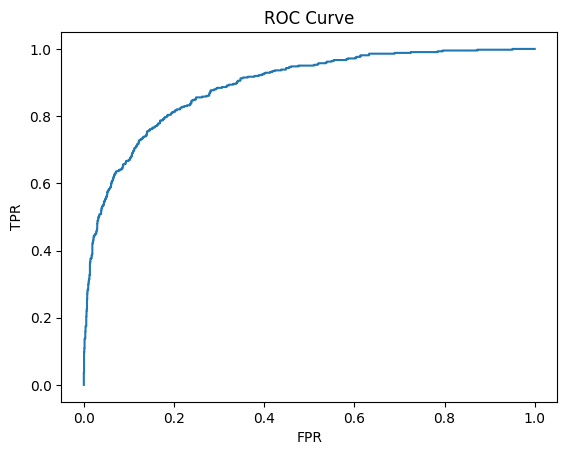

In [11]:
roc_auc = roc_auc_score(y_test, y_test_probs)
print("ROC-AUC:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_test_probs)

plt.plot(fpr, tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

PR-AUC: 0.7092226080098648


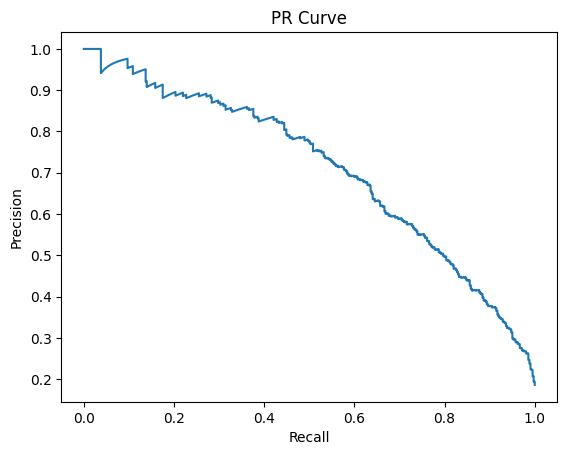

In [12]:
precision, recall, _ = precision_recall_curve(y_test, y_test_probs)
pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.show()

In [13]:
# techinque-1:: class weightage..
log_model_bal = LogisticRegression(max_iter=1000, class_weight='balanced',**grid.best_params_)

log_model_bal.fit(X_train_main_tfidf, y_train_main)

y_test_probs_bal = log_model_bal.predict_proba(X_test_tfidf)[:, 1]
y_pred_bal = (y_test_probs_bal >= best_threshold).astype(int)

print("CLASS WEIGHT RESULTS")
print(classification_report(y_test, y_pred_bal))

CLASS WEIGHT RESULTS
              precision    recall  f1-score   support

           0       0.95      0.79      0.86      1851
           1       0.47      0.82      0.60       423

    accuracy                           0.79      2274
   macro avg       0.71      0.80      0.73      2274
weighted avg       0.86      0.79      0.81      2274



c:\Users\SAD ABHIRAM\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [14]:
# techinque-2 :: smote
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_main_tfidf.toarray(), y_train_main)

log_model_smote = LogisticRegression(max_iter=1000,**grid.best_params_)

log_model_smote.fit(X_train_smote, y_train_smote)

y_test_probs_smote = log_model_smote.predict_proba(X_test_tfidf)[:, 1]
y_pred_smote = (y_test_probs_smote >= best_threshold).astype(int)

print("SMOTE RESULTS")
print(classification_report(y_test, y_pred_smote))

c:\Users\SAD ABHIRAM\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


SMOTE RESULTS
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      1851
           1       0.50      0.78      0.61       423

    accuracy                           0.81      2274
   macro avg       0.72      0.80      0.74      2274
weighted avg       0.86      0.81      0.83      2274

